<img src="http://dask.readthedocs.io/en/latest/_images/dask_horizontal.svg"
     align="right"
     width="30%"
     alt="Dask logo\">


# Dask DataFrame —— 并行化的 pandas

用起来像 pandas API，但面向并行与分布式工作流。

`dask.dataframe` 模块的核心是一个“分块并行”的 `DataFrame` 对象：接口像 pandas，却能用于并行和分布式场景。一个 Dask `DataFrame` 由许多沿索引切开、驻留内存的 pandas `DataFrame` 组成。对 Dask `DataFrame` 的一次操作，会在这些组成它的 pandas `DataFrame` 上触发许多 pandas 操作，并会顾及可能的并行度与内存限制。


<img src="https://docs.dask.org/en/stable/_images/dask-dataframe.svg"
     align="right"
     width="30%"
     alt="Dask DataFrame is composed of pandas DataFrames"/>

**相关文档**

* [DataFrame 文档](https://docs.dask.org/en/latest/dataframe.html)
* [DataFrame 视频](https://youtu.be/AT2XtFehFSQ)
* [DataFrame API](https://docs.dask.org/en/latest/dataframe-api.html)
* [DataFrame 示例](https://examples.dask.org/dataframe.html)
* [pandas 文档](https://pandas.pydata.org/pandas-docs/stable/)

## 什么时候用 `dask.dataframe`

pandas 很适合放得进内存的表格数据。关于 pandas，有一条经验法则：

> “内存大概要有数据集大小的 5 到 10 倍”
>
> ~ Wes McKinney（2017）在 [10 things I hate about pandas](https://wesmckinney.com/blog/apache-arrow-pandas-internals/)

这里的“数据集大小”指的是 **磁盘上** 的大小。

当数据超过这条经验法则时，Dask 就开始有用了。

本 notebook 会使用纽约市航班数据。这个数据集大约只有 200MB，方便在合理时间内下载，但 `dask.dataframe` 可以扩展到 **远大于内存** 的数据集。


## 创建数据集


创建本 notebook 会用到的数据集：


In [1]:
%run prep.py -d flights

## 搭建本地集群


创建一个本地 Dask 集群，并把它连到 client。这段代码先不用深究，Distributed 那一节会详细讲。


In [2]:
from dask.distributed import Client

client = Client(n_workers=4)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 15.62 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43157,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 4
Started: Just now,Total memory: 15.62 GiB
Comm: tcp://127.0.0.1:38765,Total threads: 1
Dashboard: http://127.0.0.1:40075/status,Memory: 3.90 GiB
Nanny: tcp://127.0.0.1:42769,


### Dask 诊断仪表盘

Dask Distributed 提供了很有用的 Dashboard，用来观察集群状态和计算过程。

如果你在 **JupyterLab 或 Binder** 上，可以用 [Dask JupyterLab 扩展](https://github.com/dask/dask-labextension)（环境里应该已经装好了）打开仪表盘图表：
* 点击左侧边栏的 Dask 图标
* 点击放大镜图标，它会自动连到当前活动的仪表盘（如果不行，可以把仪表盘链接 http://127.0.0.1:8787 填进输入框）
* 点击 **"Task Stream"**、**"Progress Bar"** 和 **"Worker Memory"**，这些图会在新标签页打开
* 按你的习惯重新排列标签页！

或者，点击上面 Client 详情里显示的仪表盘链接：http://127.0.0.1:8787/status。它会在新的浏览器标签页打开 Dashboard。


## 读取并使用数据集

我们来读取美国若干年份的航班摘录。这些数据特指从纽约市三个机场出发的航班。


In [3]:
import os
import dask

按惯例，我们把模块 `dask.dataframe` 导入为 `dd`，并把对应的 `DataFrame` 对象叫做 `ddf`。

**说明**：“Dask DataFrame” 这个词稍微有点超载。视上下文，它可能指模块，也可能指 DataFrame 对象。为避免混淆，本 notebook 里约定：
- `dask.dataframe`（全小写）指 API，
- `DataFrame`（驼峰）指对象。

下面的文件名包含通配符 `*`，因此路径下所有匹配的文件都会读进同一个 `DataFrame`。


In [4]:
import dask.dataframe as dd

ddf = dd.read_csv(
    os.path.join("data", "nycflights", "*.csv"), parse_dates={"Date": [0, 1, 2]}
)
ddf

,Date,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,Diverted
npartitions=10,,,,,,,,,,,,,,,,,,,,,
,datetime64[ns],int64,float64,int64,float64,int64,object,int64,float64,float64,int64,float64,float64,float64,object,object,float64,float64,float64,int64,int64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


Dask 此时还没有真正加载数据，它只是：
- 检查了输入路径，发现有十个匹配的文件
- 聪明地为每个分块创建了一组任务——在这个例子里，每个原始 CSV 文件对应一个任务


注意 `DataFrame` 对象的显示里还没有数据——Dask 只读了第一个文件的开头，用来推断列名和 dtype。


### 惰性求值（Lazy Evaluation）

包括 Dask `DataFrame` 在内，大多数 Dask 集合都是惰性求值的：Dask 会立刻构建计算的逻辑（也就是任务图），但只在必要时才真正“求值”。你可以用 `.visualize()` 查看这张任务图。

Delayed 那一节会对此讲得更多。现在只要记住：需要调用 `.compute()` 才会触发真正的计算。


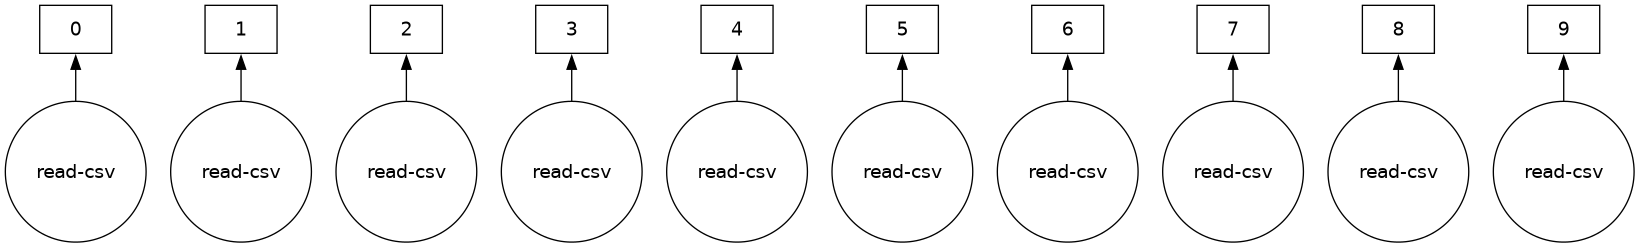

In [5]:
ddf.visualize()

有些函数（例如 `len` 和 `head`）也会触发计算。具体来说，调用 `len` 会：
- 加载实际数据（也就是把每个文件读进一个 pandas DataFrame）
- 再对每个 pandas DataFrame（也叫分区，partition）应用相应函数
- 把各部分的小计合并成最终总数


In [6]:
# 加载数据并统计行数
len(ddf)


9990

你可以像在 pandas 里那样查看数据的开头和结尾：


In [7]:
ddf.head()

,Date,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,Diverted
0,1990-01-01,1,1621.0,1540,1747.0,1701,US,33,NaN,86.0,...,NaN,46.0,41.0,EWR,PIT,319.0,NaN,NaN,0,0
1,1990-01-02,2,1547.0,1540,1700.0,1701,US,33,NaN,73.0,...,NaN,-1.0,7.0,EWR,PIT,319.0,NaN,NaN,0,0
2,1990-01-03,3,1546.0,1540,1710.0,1701,US,33,NaN,84.0,...,NaN,9.0,6.0,EWR,PIT,319.0,NaN,NaN,0,0
3,1990-01-04,4,1542.0,1540,1710.0,1701,US,33,NaN,88.0,...,NaN,9.0,2.0,EWR,PIT,319.0,NaN,NaN,0,0
4,1990-01-05,5,1549.0,1540,1706.0,1701,US,33,NaN,77.0,...,NaN,5.0,9.0,EWR,PIT,319.0,NaN,NaN,0,0


```python
ddf.tail()

# ValueError: Mismatched dtypes found in `pd.read_csv`/`pd.read_table`.

# +----------------+---------+----------+
# | Column         | Found   | Expected |
# +----------------+---------+----------+
# | CRSElapsedTime | float64 | int64    |
# | TailNum        | object  | float64  |
# +----------------+---------+----------+

# The following columns also raised exceptions on conversion:

# - TailNum
#   ValueError("could not convert string to float: 'N54711'")

# Usually this is due to dask's dtype inference failing, and
# *may* be fixed by specifying dtypes manually by adding:

# dtype={'CRSElapsedTime': 'float64',
#        'TailNum': 'object'}

# to the call to `read_csv`/`read_table`.

```


`pandas.read_csv` 会先读完整份文件再推断类型，而 `dask.dataframe.read_csv` 只从文件开头（若使用通配符，则是第一个文件）抽样。推断出的类型随后会强制应用到所有分区。

这个例子里，样本推断出的类型是错的。前 `n` 行的 `CRSElapsedTime` 没有值（pandas 会推断成 `float`），后面却变成了字符串（`object` dtype）。注意 Dask 给出了关于类型不匹配的明确报错。遇到这种情况，你有几种选择：

- 用 `dtype` 关键字直接指定类型。这是推荐做法，既最不容易出错（明确优于隐式），通常也最快。
- 增大 `sample` 关键字（按字节计）
- 使用 `assume_missing`，让 `dask` 假定被推断为 `int`（不允许缺失值）的列其实是 `float`（允许缺失值）。我们这个例子并不适用。

这里我们用第一种做法，直接指定出问题的列的 `dtype`。


In [8]:
ddf = dd.read_csv(
    os.path.join("data", "nycflights", "*.csv"),
    parse_dates={"Date": [0, 1, 2]},
    dtype={"TailNum": str, "CRSElapsedTime": float, "Cancelled": bool},
)

In [9]:
ddf.tail()  # 现在可以了


,Date,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,Diverted
994,1999-01-25,1,632.0,635,803.0,817,CO,437,N27213,91.0,...,68.0,-14.0,-3.0,EWR,RDU,416.0,4.0,19.0,False,0
995,1999-01-26,2,632.0,635,751.0,817,CO,437,N16217,79.0,...,62.0,-26.0,-3.0,EWR,RDU,416.0,3.0,14.0,False,0
996,1999-01-27,3,631.0,635,756.0,817,CO,437,N12216,85.0,...,66.0,-21.0,-4.0,EWR,RDU,416.0,4.0,15.0,False,0
997,1999-01-28,4,629.0,635,803.0,817,CO,437,N26210,94.0,...,69.0,-14.0,-6.0,EWR,RDU,416.0,5.0,20.0,False,0
998,1999-01-29,5,632.0,635,802.0,817,CO,437,N12225,90.0,...,67.0,-15.0,-3.0,EWR,RDU,416.0,5.0,18.0,False,0


### 从远程存储读取

如果你在考虑分布式计算，数据多半存在远程服务上（例如 Amazon S3 或 Google 云存储），而且格式更友好（例如 Parquet）。Dask 可以从这些远程位置 **惰性且并行地** 直接读取多种格式。

下面是从 Amazon S3 读取纽约出租车数据的写法：

```python
ddf = dd.read_parquet(
    "s3://nyc-tlc/trip data/yellow_tripdata_2012-*.parquet",
)
```

你还可以利用 Parquet 特有的优化，例如列选择和元数据处理。更多内容见 [Dask 文档中关于 Parquet 的说明](https://docs.dask.org/en/stable/dataframe-parquet.html)。


## 用 `dask.dataframe` 做计算

我们来计算航班延误的最大值。

如果只用 pandas，我们会循环处理每个文件，找出各自的最大值，再在这些最大值里取总的最大。

```python
import pandas as pd

files = os.listdir(os.path.join('data', 'nycflights'))

maxes = []

for file in files:
    df = pd.read_csv(os.path.join('data', 'nycflights', file))
    maxes.append(df.DepDelay.max())
    
final_max = max(maxes)
```

`dask.dataframe` 让我们能写类似 pandas 的代码，在大于内存的数据集上并行运算。


In [10]:
%%time
result = ddf.DepDelay.max()
result.compute()

CPU times: user 23.9 ms, sys: 2.53 ms, total: 26.5 ms
Wall time: 63.2 ms


409.0

这会为我们创建惰性计算，然后执行它。


**注意：** Dask 会尽快删除中间结果（例如每个文件对应的完整 pandas DataFrame）。因此你可以处理大于内存的数据集，但重复计算每次都得重新加载全部数据。（再跑一遍上面的代码，它比你预期的更快还是更慢？）


可以用 `.visualize()` 查看底层任务图：


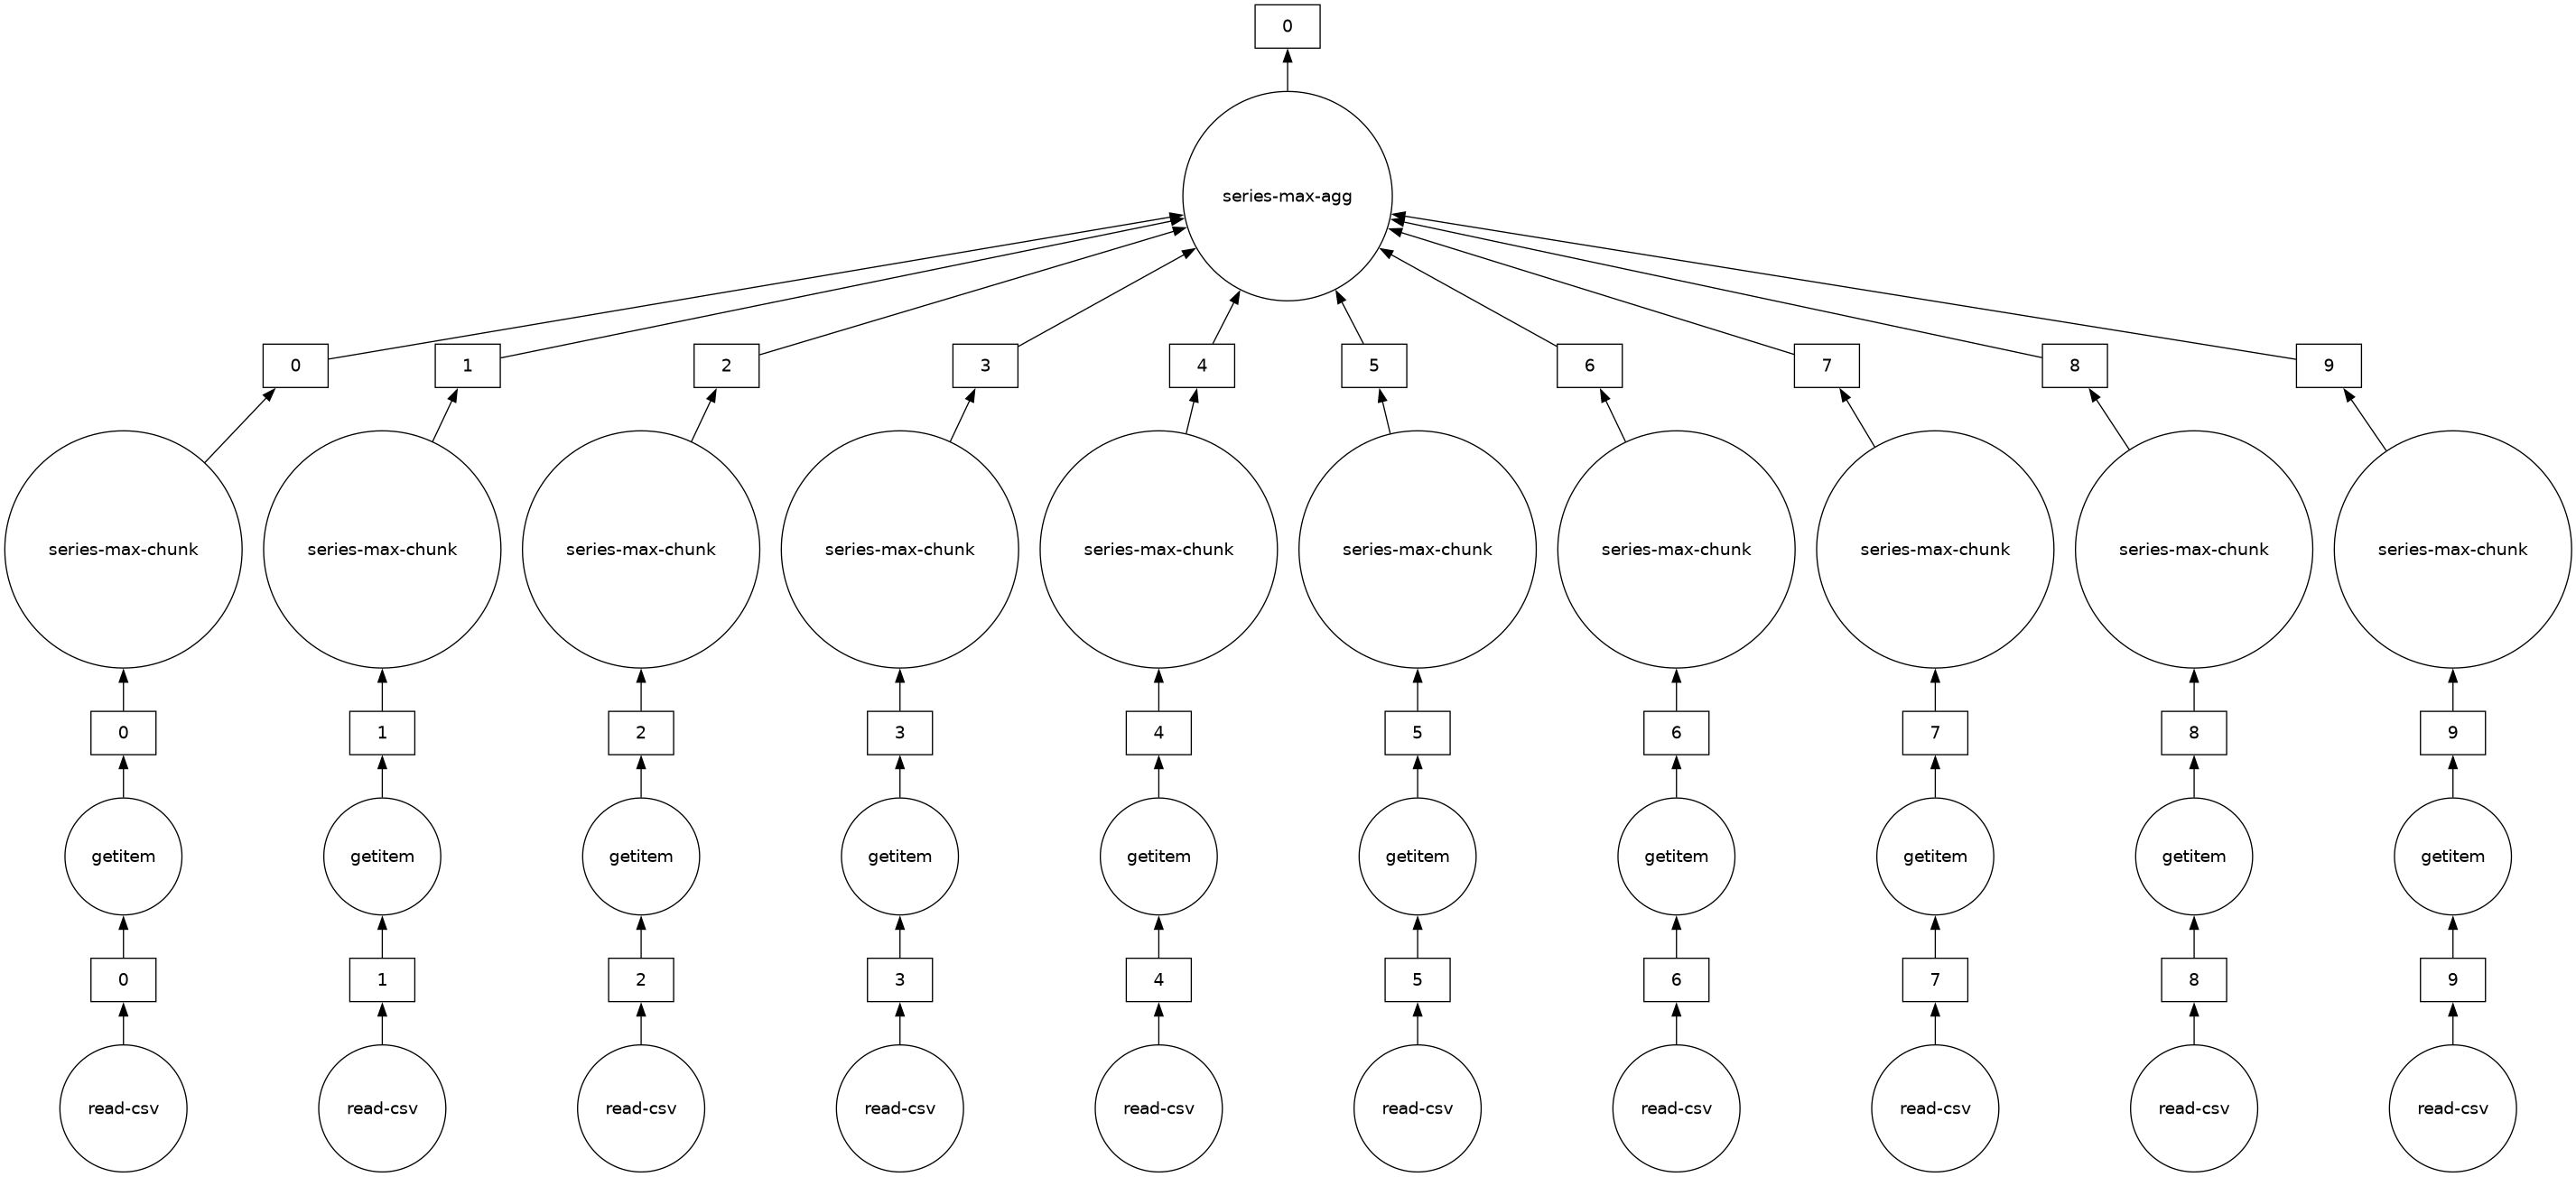

In [11]:
# 注意其中的并行
result.visualize()


## 练习

这一节你会做几个 `dask.dataframe` 计算。如果熟悉 pandas，这些应该不陌生。你需要想清楚何时调用 `.compute()`。


### 1. 数据集里有多少行？

_提示_：你会怎么检查一个列表里有多少元素？


In [12]:
# 在此编写代码


In [13]:
len(ddf)

9990

### 2. 总共有多少次未取消的航班？

_提示_：使用 [布尔索引](https://pandas.pydata.org/pandas-docs/stable/indexing.html#boolean-indexing)。


In [14]:
# 在此编写代码


In [15]:
len(ddf[~ddf.Cancelled])

9383

### 3. 每个机场总共有多少次未取消的航班？

*提示*：使用 [groupby](https://pandas.pydata.org/pandas-docs/stable/groupby.html)。


In [16]:
# 在此编写代码


In [17]:
ddf[~ddf.Cancelled].groupby("Origin").Origin.count().compute()

Origin
EWR    4132
JFK    1085
LGA    4166
Name: Origin, dtype: int64

### 4. 每个机场的平均起飞延误是多少？


In [18]:
# 在此编写代码


In [19]:
ddf.groupby("Origin").DepDelay.mean().compute()

Origin
EWR    12.500968
JFK    17.053456
LGA    10.169227
Name: DepDelay, dtype: float64

### 5. 一周中哪一天的平均起飞延误最严重？


In [20]:
# 在此编写代码


In [21]:
ddf.groupby("DayOfWeek").DepDelay.mean().idxmax().compute()

5

### 6. 假设 distance 列有误，你需要给所有值加 1，该怎么做？


In [22]:
# 在此编写代码


In [23]:
ddf["Distance"].apply(
    lambda x: x + 1
).compute()  # 先不用担心这个警告，下一节会讨论

# 或者

(ddf["Distance"] + 1).compute()


/usr/share/miniconda/envs/dask-tutorial/lib/python3.10/site-packages/dask/dataframe/core.py:4139: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, meta=('Distance', 'float64'))

  warnings.warn(meta_warning(meta))


0      320.0
1      320.0
2      320.0
3      320.0
4      320.0
       ...  
994    417.0
995    417.0
996    417.0
997    417.0
998    417.0
Name: Distance, Length: 9990, dtype: float64

## 共享中间结果

做上面这些计算时，有时会对同一操作算了不止一次。对大多数操作，`dask.dataframe` 会保存参数，从而让重复计算被共享，只真正算一次。

例如，我们来计算所有未取消航班起飞延误的均值和标准差。因为 Dask 操作是惰性的，这些值还不是最终结果，只是得到结果所需的步骤。

如果用两次 `compute` 分别计算，中间计算不会被共享。


In [24]:
non_canceled = ddf[~ddf.Cancelled]
mean_delay = non_canceled.DepDelay.mean()
std_delay = non_canceled.DepDelay.std()

In [25]:
%%time

mean_delay_res = mean_delay.compute()
std_delay_res = std_delay.compute()

CPU times: user 61.7 ms, sys: 6.77 ms, total: 68.5 ms
Wall time: 161 ms


### `dask.compute`


这次试着把两者一起传给一次 `compute` 调用。


In [26]:
%%time

mean_delay_res, std_delay_res = dask.compute(mean_delay, std_delay)

CPU times: user 51.9 ms, sys: 5.99 ms, total: 57.9 ms
Wall time: 101 ms


使用 `dask.compute` 大约只要一半时间。因为调用 `dask.compute` 时，两个结果的任务图会被合并，共享的操作只做一次而不是两次。具体来说，`dask.compute` 只会各做一次：

- 对 `read_csv` 的调用
- 过滤（`df[~df.Cancelled]`）
- 一部分必要的归约（`sum`、`count`）


要看多个结果合并后的任务图（以及哪些部分是共享的），可以使用 `dask.visualize` 函数（你可能想加上 `filename='graph.pdf'` 把图存到磁盘，方便放大查看）：


In [27]:
dask.visualize(mean_delay, std_delay, engine="cytoscape")

CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'rankDir': 'BT', 'nodeSep': 10, 'edgeSep': 10, 'spacingFact…

### `.persist()`

使用分布式调度器时（后续 notebook 会更详细地讲调度器），你可以把一些 _经常要用的数据_ 留在 _分布式内存_ 里。

`persist` 会生成 “Futures”（后面也会讲），并把它们存放在与输出相同的结构里。任何能放进内存的数据或计算都可以使用 `persist`。


如果你只想分析从 JFK 机场出发、且未被取消的航班，可以像上一节那样调用两次 compute：


In [28]:
non_cancelled = ddf[~ddf.Cancelled]
ddf_jfk = non_cancelled[non_cancelled.Origin == "JFK"]

In [29]:
%%time
ddf_jfk.DepDelay.mean().compute()
ddf_jfk.DepDelay.sum().compute()

CPU times: user 144 ms, sys: 5.98 ms, total: 150 ms
Wall time: 246 ms


18503.0

也可以考虑把那一部分数据 persist 到内存里。

看仪表盘上的 “Graph” 图，红色方块表示作为 Future 存在内存里的 persist 数据。你还会注意到 Worker Memory（另一张仪表盘图）占用上升。


In [30]:
ddf_jfk = ddf_jfk.persist()  # 立刻把控制权交还给你


In [31]:
%%time
ddf_jfk.DepDelay.mean().compute()
ddf_jfk.DepDelay.std().compute()

CPU times: user 69.1 ms, sys: 3.93 ms, total: 73 ms
Wall time: 131 ms


36.85799641792652

在这份 persist 过的数据上做分析会更快，因为我们不用重复加载和筛选（未取消、从 JFK 出发）。


## 在 Dask DataFrame 上使用自定义代码

`dask.dataframe` 只覆盖了 pandas API 中较小但常用的一部分。

之所以有这个限制，有两个原因：

1.  Pandas 的 API *非常大*
2.  有些操作本身就很难并行，例如排序。

另外，像 `set_index` 这类重要操作虽然能用，但比 pandas 慢，因为它们包含大量数据洗牌（shuffle），还可能写磁盘。

**如果你想用一些 Dask DataFrame 还没实现（或没法实现）的自定义函数，该怎么办？**

可以在 [Dask issue tracker](https://github.com/dask/dask/issues) 开一个 issue，问问实现这个函数有多可行，也可以考虑把函数贡献给 Dask。

如果它是自定义函数，或实现起来很棘手，`dask.dataframe` 提供了几种方法，让自定义函数更容易作用在 Dask DataFrame 上：

- [`map_partitions`](https://docs.dask.org/en/latest/generated/dask.dataframe.DataFrame.map_partitions.html)：在 Dask DataFrame 的每个分区（每个 pandas DataFrame）上运行函数
- [`map_overlap`](https://docs.dask.org/en/latest/generated/dask.dataframe.rolling.map_overlap.html)：在每个分区上运行函数，并在相邻分区之间共享若干行
- [`reduction`](https://docs.dask.org/en/latest/generated/dask.dataframe.Series.reduction.html)：用于自定义的按行归约操作


我们快速看一下 `map_partitions()` 函数：


In [32]:
help(ddf.map_partitions)

Help on method map_partitions in module dask.dataframe.core:

map_partitions(func, *args, **kwargs) method of dask.dataframe.core.DataFrame instance
    Apply Python function on each DataFrame partition.
    
    Note that the index and divisions are assumed to remain unchanged.
    
    Parameters
    ----------
    func : function
        The function applied to each partition. If this function accepts
        the special ``partition_info`` keyword argument, it will receive
        information on the partition's relative location within the
        dataframe.
    args, kwargs :
        Positional and keyword arguments to pass to the function.
        Positional arguments are computed on a per-partition basis, while
        keyword arguments are shared across all partitions. The partition
        itself will be the first positional argument, with all other
        arguments passed *after*. Arguments can be ``Scalar``, ``Delayed``,
        or regular Python objects. DataFrame-like args

`ddf` 里的 "Distance" 列目前以英里为单位。假设我们想把它转成公里，并且已经有下面这个通用辅助函数。这时可以用 `map_partitions`，把函数并行应用到内部的每个 pandas `DataFrame` 上。


In [33]:
import pandas as pd


def my_custom_converter(df, multiplier=1):
    return df * multiplier


meta = pd.Series(name="Distance", dtype="float64")

distance_km = ddf.Distance.map_partitions(
    my_custom_converter, multiplier=0.6, meta=meta
)


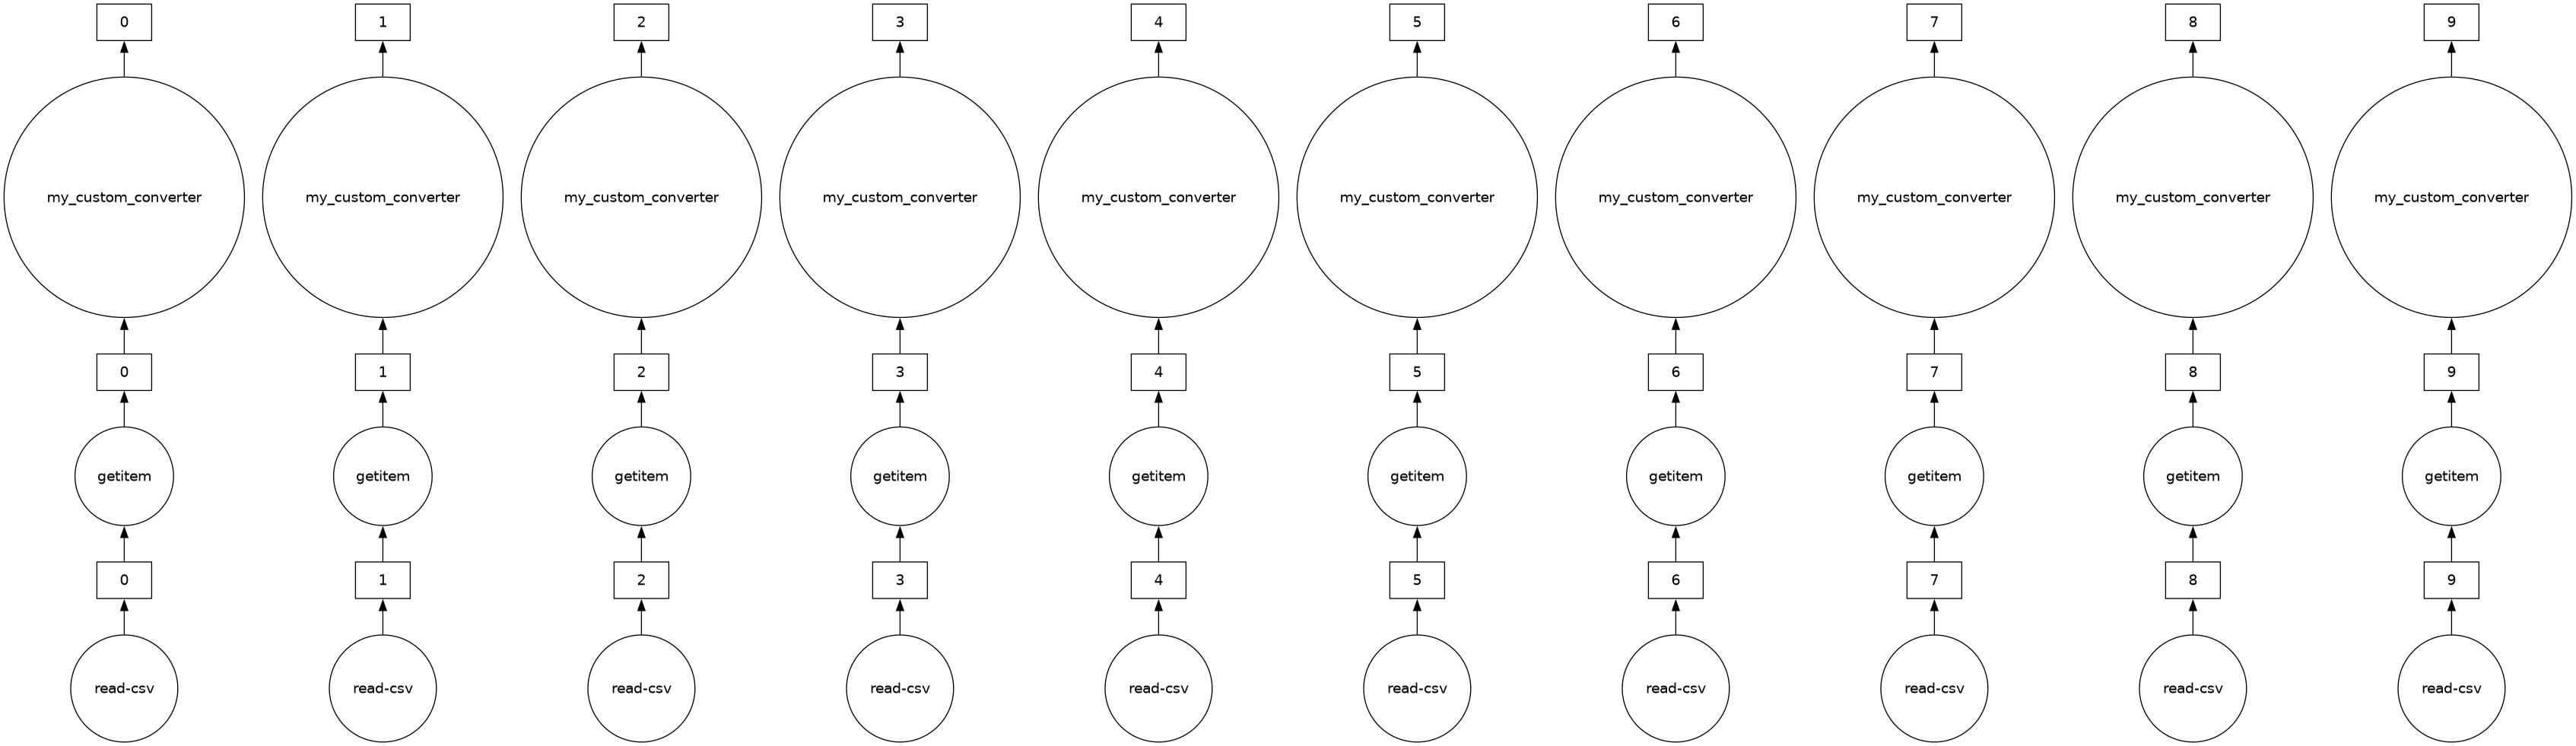

In [34]:
distance_km.visualize()

In [35]:
distance_km.head()

0    191.4
1    191.4
2    191.4
3    191.4
4    191.4
Name: Distance, dtype: float64

### 什么是 `meta`？

因为 Dask 是惰性执行的，它并不总有足够信息来推断某些操作的输出结构（包括数据类型）。

`meta` 是给 Dask 的一个 _提示_，说明你的计算输出长什么样。重要的是，`meta` _不会去干涉_ 最终的输出结构。在 Dask 能确定真实输出结构之前，它会先使用这个 `meta`。

定义 `meta` 的方法有很多，我们建议用一个很小的 pandas Series 或 DataFrame，使其结构与最终输出一致。


## 关闭本地 Dask 集群


养成习惯：自己创建的 Dask 集群用完后都关掉。


In [36]:
client.shutdown()